<a href="https://colab.research.google.com/github/Harold-dev-code/TelecomX_Parte2_Tercer-Challenge/blob/main/TelecomX_Parte2_Tercer_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$\huge \text{🤖 challenge_Telecom-X (Parte 2: Machine Learning)}$$



Nota: Este proyecto es la continuación directa del análisis exploratorio. Puedes ver la Fase 1 (EDA,Limpieza y transformación de datos) aquí: https://github.com/Harold-dev-code/challenge_Telecom-X_parte_uno



<h2>Proyecto de análisis predictivo orientado a la retención de clientes. Implementación de modelos de clasificación en Python para identificar factores críticos que influyen en la cancelación de servicios de Telecom X.</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#📥 Extracción

In [2]:
df=pd.read_csv('/content/datos_telecomX_procesados.csv')

In [3]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## 🔍👀🔎 Revisión - Verificación

###sabemos que ya nuestro dateset esta tratado anteriormente , pero vamos a preparlos para adecuarlo para el proceso de machine learning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   objec

### Observamos que el tipo de dato en customer.seniorCitizaen es int64 pero es una variable binaria que indica si el cliente es una persona mayor (1) o no (0)el modelo lo interpretará correctamente como una variable binaria. No necesito cambiarle el tipo de dato.

###Para customer.tenure que tambien es Tipo int64, esta es una variable numérica continua (meses de antigüedad). Aquí depende el modelo predictivo que vamos a elejir:

Si usamos **Regresión Logística:** Aplicaremos un escalado (como StandardScaler). Como tenure puede ir de 0 a 72 meses y otras variables solo son 0 o 1, el modelo podría pensar que la antigüedad es "más importante" solo porque el número es más grande.

Si usamos **Random Forest:** No necesitamos hacer nada. Este modelo no se ve afectado por la diferencia de escalas entre meses y valores binarios.

### Charges.Monthly y Charges.Total: Ambos están como float64, listos para cálculos matemáticos.

### Variables object: Tenemos 17 columnas no númericas(como gender, Partner, Dependents, etc.). Estas sí necesitan ser transformadas a números (usando One-Hot Encoding o Label Encoding) antes de entrenar cualquier modelo o descartarlas las variables que no son necesarias para influir en la cancelación de servicios de Telecom X.

In [5]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

#🗑 Eliminación de Columnas Irrelevantes

### Quitamos el customerID que es el id del cliente. esta no posee una característica predictiva

> Agregar bloque entrecomillado



In [6]:
df = df.drop('customerID', axis=1)

In [7]:
df.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7043 non-null   object 
 1   customer.gender            7043 non-null   object 
 2   customer.SeniorCitizen     7043 non-null   int64  
 3   customer.Partner           7043 non-null   object 
 4   customer.Dependents        7043 non-null   object 
 5   customer.tenure            7043 non-null   int64  
 6   phone.PhoneService         7043 non-null   object 
 7   phone.MultipleLines        7043 non-null   object 
 8   internet.InternetService   7043 non-null   object 
 9   internet.OnlineSecurity    7043 non-null   object 
 10  internet.OnlineBackup      7043 non-null   object 
 11  internet.DeviceProtection  7043 non-null   object 
 12  internet.TechSupport       7043 non-null   object 
 13  internet.StreamingTV       7043 non-null   objec

# 💻 Encoding

###Antes de comenzar a transformar en binario las variables categóricas,  análizamos que variables tiene más de 2 valores unicos

In [24]:
print("Columnas categóricas con más de 2 valores únicos: ")

# Seleccionar solo las columnas de tipo 'object' del DataFrame original (antes del encoding)
categorical_cols_original = df.select_dtypes(include='object').columns.tolist()

# vamos a mirar las columnas originales (object) de df y verificar si tienen más de 2 valores únicos
for col in categorical_cols_original:
    unique_values_count = df[col].nunique()
    if unique_values_count > 2:
        print(f"- Columna '{col}': {unique_values_count} valores únicos")
        print(f"  Valores únicos: {df[col].unique()}")


Columnas categóricas con más de 2 valores únicos: 
- Columna 'phone.MultipleLines': 3 valores únicos
  Valores únicos: ['No' 'Yes' 'No phone service']
- Columna 'internet.InternetService': 3 valores únicos
  Valores únicos: ['DSL' 'Fiber optic' 'No']
- Columna 'internet.OnlineSecurity': 3 valores únicos
  Valores únicos: ['No' 'Yes' 'No internet service']
- Columna 'internet.OnlineBackup': 3 valores únicos
  Valores únicos: ['Yes' 'No' 'No internet service']
- Columna 'internet.DeviceProtection': 3 valores únicos
  Valores únicos: ['No' 'Yes' 'No internet service']
- Columna 'internet.TechSupport': 3 valores únicos
  Valores únicos: ['Yes' 'No' 'No internet service']
- Columna 'internet.StreamingTV': 3 valores únicos
  Valores únicos: ['Yes' 'No' 'No internet service']
- Columna 'internet.StreamingMovies': 3 valores únicos
  Valores únicos: ['No' 'Yes' 'No internet service']
- Columna 'account.Contract': 3 valores únicos
  Valores únicos: ['One year' 'Month-to-month' 'Two year']
- Colu

### Observamos que varias variables de servicio de internet contiene un tercer valor llamado 'No internet service'. No tiene sentido que un cliente que no tiene internet tenga 'seguridad en línea', backup en línea, streming...y otros servicios que necesitan internet por lo que 'No internet service' es funcionalmente lo mismo que 'No' para esas características específicas.

In [31]:
print("\nColumnas que contienen 'No internet service' en sus registros (en el DataFrame original 'df'):")
for col in df.columns:
    if df[col].dtype == 'object': # Solo revisamos columnas de texto
        if 'No internet service' in df[col].unique():
            print(f"- Columna '{col}' contiene 'No internet service'.")



Columnas que contienen 'No internet service' en sus registros (en el DataFrame original 'df'):
- Columna 'internet.OnlineSecurity' contiene 'No internet service'.
- Columna 'internet.OnlineBackup' contiene 'No internet service'.
- Columna 'internet.DeviceProtection' contiene 'No internet service'.
- Columna 'internet.TechSupport' contiene 'No internet service'.
- Columna 'internet.StreamingTV' contiene 'No internet service'.
- Columna 'internet.StreamingMovies' contiene 'No internet service'.


###Ya tenemos identificadas las variables con 'No internet service', también observe que la variable o columna  **phone.MultipleLines** tiene un valor similar 'No phone service' y se le puede aplicar la misma lógica: Si un cliente no tiene servicio telefónico (phone.PhoneService es 'No'), entonces lógicamente no puede tener 'múltiples líneas'. Por lo tanto, el valor 'No phone service' en la columna phone.MultipleLines es funcionalmente equivalente a 'No' (es decir, no tiene múltiples líneas porque no tiene ni siquiera una línea principal).

In [35]:
#verificamos
df[df['phone.MultipleLines'] == 'No phone service'].sample(10)

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
5734,No,Female,0,Yes,Yes,67,No,No phone service,DSL,Yes,No,No,Yes,No,No,Two year,No,Credit card (automatic),35.70,2545.70
412,Yes,Female,1,No,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,25.25,25.25
3894,Yes,Female,1,No,No,3,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,25.30,77.75
6866,No,Female,0,Yes,Yes,26,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),38.85,1025.15
1150,No,Male,0,Yes,Yes,39,No,No phone service,DSL,No,No,No,No,No,No,One year,Yes,Credit card (automatic),25.25,947.75
4364,Yes,Male,0,Yes,No,9,No,No phone service,DSL,No,No,No,No,No,No,One year,No,Bank transfer (automatic),24.10,259.80
6143,No,Male,0,No,No,21,No,No phone service,DSL,Yes,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,43.55,1011.50
2337,Yes,Female,1,Yes,No,18,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,48.35,810.70
1605,No,Male,0,No,Yes,23,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,Two year,No,Mailed check,40.10,857.75
4598,No,Male,0,Yes,Yes,56,No,No phone service,DSL,No,Yes,Yes,No,No,No,One year,Yes,Credit card (automatic),36.10,1971.50


###Ya identificadas las varibles categóricas que podemos simplificar procedemos, primero a simplificar y despues hacer el encoding a las variables

In [47]:
df_encoded = df.copy()

# Identificar las columnas de servicios de internet que contienen 'No internet service'
internet_service_cols = [
    'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport',
    'internet.StreamingTV', 'internet.StreamingMovies'
]

# Reemplazar 'No internet service' con 'No' en estas columnas específicas
for col in internet_service_cols:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].replace('No internet service', 'No')

# Reemplazar 'No phone service' con 'No' en la columna 'phone.MultipleLines'
if 'phone.MultipleLines' in df_encoded.columns:
    df_encoded['phone.MultipleLines'] = df_encoded['phone.MultipleLines'].replace('No phone service', 'No')

# Identificar columnas de tipo 'object' que no sean la variable objetivo 'Churn'
categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

# Aplicar One-Hot Encoding a las columnas categóricas
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=False)

# Para la variable objetivo 'Churn', convertir a binario (0 y 1)
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})



print("\nInformación del DataFrame después del One-Hot Encoding:\n")
df_encoded.info()
print("---------------------------------------------------------------------------------------")
print("---------------------------------------------------------------------------------------")

df_encoded


Información del DataFrame después del One-Hot Encoding:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Churn                                            7043 non-null   int64  
 1   customer.SeniorCitizen                           7043 non-null   int64  
 2   customer.tenure                                  7043 non-null   int64  
 3   account.Charges.Monthly                          7043 non-null   float64
 4   account.Charges.Total                            7043 non-null   float64
 5   customer.gender_Female                           7043 non-null   bool   
 6   customer.gender_Male                             7043 non-null   bool   
 7   customer.Partner_No                              7043 non-null   bool   
 8   customer.Partner_Yes                             7

,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,customer.gender_Female,customer.gender_Male,customer.Partner_No,customer.Partner_Yes,customer.Dependents_No,...,internet.StreamingMovies_Yes,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_No,account.PaperlessBilling_Yes,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.60,593.30,True,False,False,True,False,...,False,False,True,False,False,True,False,False,False,True
1,0,0,9,59.90,542.40,False,True,True,False,True,...,True,True,False,False,True,False,False,False,False,True
2,1,0,4,73.90,280.85,False,True,True,False,True,...,False,True,False,False,False,True,False,False,True,False
3,1,1,13,98.00,1237.85,False,True,False,True,True,...,True,True,False,False,False,True,False,False,True,False
4,1,1,3,83.90,267.40,True,False,False,True,True,...,False,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,13,55.15,742.90,True,False,True,False,True,...,False,False,True,False,True,False,False,False,False,True
7039,1,0,22,85.10,1873.70,False,True,False,True,True,...,True,True,False,False,False,True,False,False,True,False
7040,0,0,2,50.30,92.75,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
7041,0,0,67,67.85,4627.65,False,True,False,True,False,...,True,False,False,True,True,False,False,False,False,True


#🔍📉Verificación de la Proporción de Cancelación (Churn)

In [54]:
# Calcular la proporción de clientes que cancelaron (Churn=1) vs. activos (Churn=0)
churn_counts = df_encoded['Churn'].value_counts()
churn_proportions = df_encoded['Churn'].value_counts(normalize=True) * 100

print("Distribución de la variable 'Churn':\n")
print("Conteo absoluto:")
print(churn_counts)
print("\nProporción (%):")
print(churn_proportions)



Distribución de la variable 'Churn':

Conteo absoluto:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporción (%):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


##Observación: Existe un desbalance significativo en las clases. La clase minoritaria (Churn=1) representa menos del 30% del total.
Esto es común en problemas de predicción de churn. Se deberán considerar técnicas de manejo de desbalance (e.g., sobremuestreo, submuestreo, SMOTE, ajuste de pesos de clase) al entrenar los modelos predictivos para evitar que el modelo ignore la clase minoritaria.

#⚖️ Balanceo de Clases

## 📊 Separación de Datos para el Modelado

In [72]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve


# Separar características (X) y variable objetivo (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usamos stratify=y para asegurar que la proporción de clases sea similar en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

print("\nDistribución de la clase 'Churn' en y_train antes de SMOTE:")
print(y_train.value_counts(normalize=True) * 100)

# Aplicar SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote_unscaled, y_train_smote_unscaled = smote.fit_resample(X_train, y_train)

print("\nDistribución de la clase 'Churn' en y_train después de SMOTE:")
print(y_train_smote_unscaled.value_counts(normalize=True) * 100)


Dimensiones de X_train: (4930, 38)
Dimensiones de y_train: (4930,)
Dimensiones de X_test: (2113, 38)
Dimensiones de y_test: (2113,)

Distribución de la clase 'Churn' en y_train antes de SMOTE:
Churn
0    73.46856
1    26.53144
Name: proportion, dtype: float64

Distribución de la clase 'Churn' en y_train después de SMOTE:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


## ⚙️ Entrenamiento del Modelo: Regresión Logística (Baseline)

In [73]:
# Inicializar y entrenar el modelo de Regresión Logística
model_unscaled = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model_unscaled.fit(X_train_smote_unscaled, y_train_smote_unscaled)

print("Modelo de Regresión Logística entrenado correctamente ")


Modelo de Regresión Logística entrenado correctamente 


## 📈 Evaluación del Modelo


Accuracy del modelo : 0.7766209181258874

Reporte de Clasificación :
               precision    recall  f1-score   support

           0       0.86      0.83      0.85      1552
           1       0.57      0.62      0.60       561

    accuracy                           0.78      2113
   macro avg       0.72      0.73      0.72      2113
weighted avg       0.78      0.78      0.78      2113


Área bajo la curva ROC (AUC-ROC): 0.830574544719481


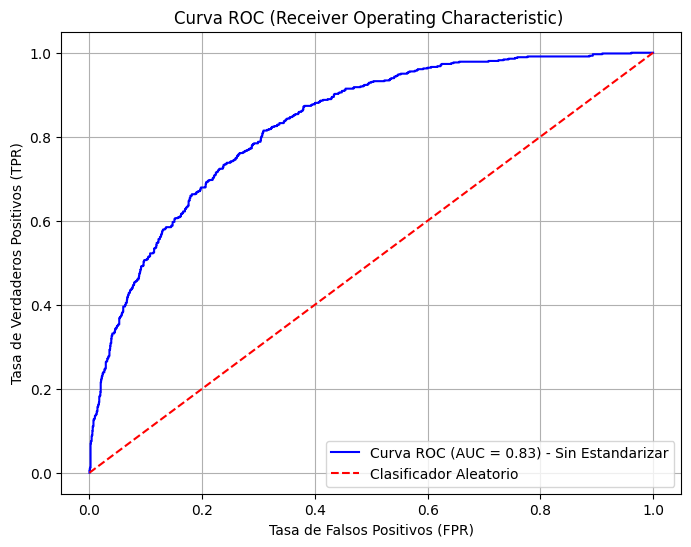

In [74]:
# Predicciones en el conjunto de prueba
y_pred_unscaled = model_unscaled.predict(X_test)
y_pred_proba_unscaled = model_unscaled.predict_proba(X_test)[:, 1] # Probabilidades de la clase positiva (Churn=1)

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo :", accuracy_score(y_test, y_pred_unscaled))
print("\nReporte de Clasificación :\n", classification_report(y_test, y_pred_unscaled))
print("\nÁrea bajo la curva ROC (AUC-ROC):", roc_auc_score(y_test, y_pred_proba_unscaled))

# Curva ROC
fpr_unscaled, tpr_unscaled, thresholds_unscaled = roc_curve(y_test, y_pred_proba_unscaled)
plt.figure(figsize=(8, 6))
plt.plot(fpr_unscaled, tpr_unscaled, color='blue', label=f'Curva ROC (AUC = {roc_auc_score(y_test, y_pred_proba_unscaled):.2f}) - Sin Estandarizar')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) ')
plt.legend()
plt.grid(True)
plt.show()


###El modelo de Regresión Logística, combinado con SMOTE para manejar el desbalance, es un buen punto de partida y muestra un prometedor poder discriminatorio (según el AUC). Sin embargo, su rendimiento en la identificación de la clase minoritaria (Churn=1) es moderado.

# ✨ Estandarización de Datos para el Modelo Escalado

In [63]:
from sklearn.preprocessing import StandardScaler

# Crear copias de los conjuntos de entrenamiento y prueba para la estandarización
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
y_train_scaled = y_train.copy() # y_train no necesita estandarización, pero la renombramos para coherencia
y_test_scaled = y_test.copy() # y_test no necesita estandarización, pero la renombramos para coherencia

# Identificar columnas numéricas para estandarizar (excluyendo las booleanas generadas por One-Hot Encoding)
numerical_cols = X_train_scaled.select_dtypes(include=['int64', 'float64']).columns

# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar el scaler solo con los datos de entrenamiento y transformar ambos conjuntos
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_scaled[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_scaled[numerical_cols])

print("\nDatos numéricos estandarizados.")

# Aplicar SMOTE al conjunto de entrenamiento estandarizado
smote_scaled = SMOTE(random_state=42)
X_train_smote_scaled, y_train_smote_scaled = smote_scaled.fit_resample(X_train_scaled, y_train_scaled)

print("\nDistribución de la clase 'Churn' en y_train después de SMOTE (con datos estandarizados):")
print(y_train_smote_scaled.value_counts(normalize=True) * 100)



Datos numéricos estandarizados.

Distribución de la clase 'Churn' en y_train después de SMOTE (con datos estandarizados):
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


## ⚙️ Entrenamiento del Modelo: Regresión Logística (con datos Estandarizados)

In [64]:
# Inicializar y entrenar el modelo de Regresión Logística con datos estandarizados
model_scaled = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model_scaled.fit(X_train_smote_scaled, y_train_smote_scaled)

print("Modelo de Regresión Logística entrenado correctamente con datos estandarizados.")


Modelo de Regresión Logística entrenado correctamente con datos estandarizados.


## 📈 Evaluación del Modelo (con datos Estandarizados)


Accuracy del modelo con datos estandarizados: 0.779460482725982

Reporte de Clasificación (con datos estandarizados):
               precision    recall  f1-score   support

           0       0.88      0.81      0.84      1552
           1       0.57      0.69      0.62       561

    accuracy                           0.78      2113
   macro avg       0.72      0.75      0.73      2113
weighted avg       0.80      0.78      0.79      2113


Área bajo la curva ROC (AUC-ROC) con datos estandarizados: 0.8365090412922433


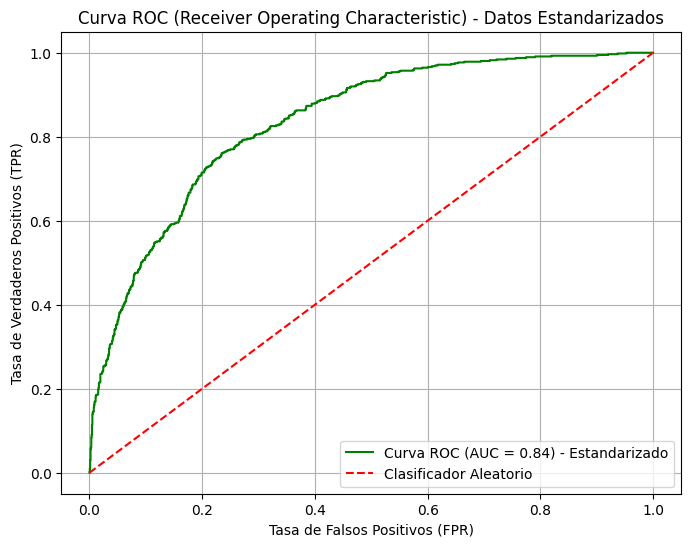

In [65]:
# Predicciones en el conjunto de prueba (que ya está estandarizado)
y_pred_scaled = model_scaled.predict(X_test_scaled)
y_pred_proba_scaled = model_scaled.predict_proba(X_test_scaled)[:, 1] # Probabilidades de la clase positiva (Churn=1)

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo con datos estandarizados:", accuracy_score(y_test_scaled, y_pred_scaled))
print("\nReporte de Clasificación (con datos estandarizados):\n", classification_report(y_test_scaled, y_pred_scaled))
print("\nÁrea bajo la curva ROC (AUC-ROC) con datos estandarizados:", roc_auc_score(y_test_scaled, y_pred_proba_scaled))

# Curva ROC
fpr_scaled, tpr_scaled, thresholds_scaled = roc_curve(y_test_scaled, y_pred_proba_scaled)
plt.figure(figsize=(8, 6))
plt.plot(fpr_scaled, tpr_scaled, color='green', label=f'Curva ROC (AUC = {roc_auc_score(y_test_scaled, y_pred_proba_scaled):.2f}) - Estandarizado')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) - Datos Estandarizados')
plt.legend()
plt.grid(True)
plt.show()


## 📊 Comparación de Modelos: Sin Estandarizar vs. Estandarizado

Al comparar los resultados de la Regresión Logística con datos **sin estandarizar** y **estandarizados**, observamos una leve mejora general, especialmente relevante para nuestro objetivo de predecir el Churn.

### **Resultados Clave:**

| Métrica             | Modelo Sin Estandarizar | Modelo Estandarizado | Comentario                                                                      |
| :------------------ | :---------------------- | :------------------- | :------------------------------------------------------------------------------ |
| **Accuracy**        | 0.7766                  | 0.7795               | Ligera mejora general, pero la Accuracy puede ser engañosa en datos desbalanceados. |
| **Precision (Churn=1)** | 0.57                    | 0.57                 | Se mantuvo igual. De cada 100 clientes predichos como Churn, 57 realmente lo fueron. |
| **Recall (Churn=1)**    | 0.62                    | **0.69**             | **Mejora significativa.** El modelo estandarizado detecta el 69% de los clientes que realmente cancelan, frente al 62% del modelo sin estandarizar. |
| **F1-Score (Churn=1)**  | 0.60                    | **0.62**             | Refleja la mejora en el Recall, indicando un mejor equilibrio entre Precision y Recall para la clase minoritaria. |
| **AUC-ROC**         | 0.8306                  | **0.8365**           | **Mejora.** El modelo estandarizado tiene una mejor capacidad general para discriminar entre las clases de Churn y No-Churn. |

### **Conclusión de la Comparación:**

La **estandarización de las características numéricas ha demostrado ser beneficiosa** para el modelo de Regresión Logística en este problema de predicción de Churn.

Aunque la mejora en el `Accuracy` general fue leve, lo más importante es el **aumento notable en el `Recall` y el `AUC-ROC` para la clase minoritaria (Churn=1)**. Esto significa que el modelo estandarizado es significativamente mejor identificando a los clientes que realmente tienen una alta probabilidad de cancelar, lo cual es de gran valor para implementar estrategias de retención más efectivas.

Esta validación refuerza la importancia de aplicar el preprocesamiento adecuado según la sensibilidad de cada algoritmo a la escala de los datos.

## 🌳 Entrenamiento del Modelo: Random Forest

In [77]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar y entrenar el modelo de Random Forest
# Usamos los datos balanceados con SMOTE pero SIN estandarizar, ya que Random Forest no es sensible a la escala.
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote_unscaled, y_train_smote_unscaled)

print("Modelo Random Forest entrenado correctamente.")


Modelo Random Forest entrenado correctamente.


## 📊 Evaluación del Modelo Random Forest


Accuracy del modelo Random Forest: 0.7770941788925698

Reporte de Clasificación (Random Forest):
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1552
           1       0.59      0.51      0.55       561

    accuracy                           0.78      2113
   macro avg       0.71      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113


Área bajo la curva ROC (AUC-ROC) Random Forest: 0.8125918830512524


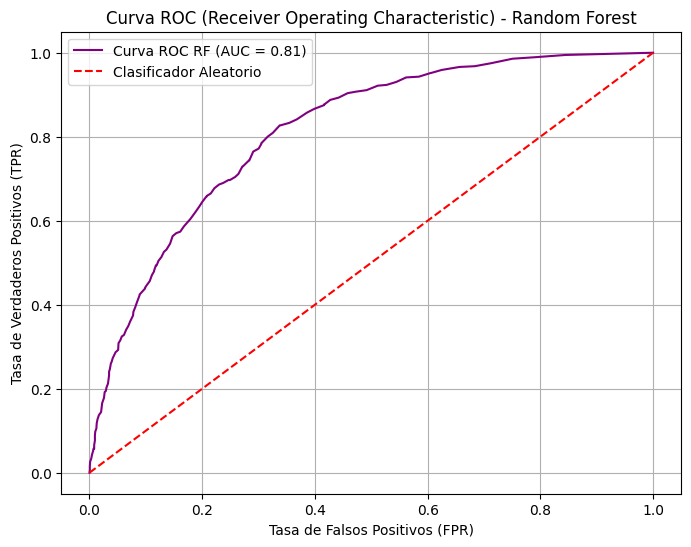

In [78]:
# Predicciones en el conjunto de prueba (no estandarizado)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nReporte de Clasificación (Random Forest):\n", classification_report(y_test, y_pred_rf))
print("\nÁrea bajo la curva ROC (AUC-ROC) Random Forest:", roc_auc_score(y_test, y_pred_proba_rf))

# Curva ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='purple', label=f'Curva ROC RF (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) - Random Forest')
plt.legend()
plt.grid(True)
plt.show()


## 🚀 Entrenamiento del Modelo: XGBoost

In [81]:
from xgboost import XGBClassifier

# Inicializar y entrenar el modelo XGBoost
# Usamos los datos balanceados con SMOTE pero SIN estandarizar.
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_smote_unscaled, y_train_smote_unscaled)

print("Modelo XGBoost entrenado correctamente.")


Modelo XGBoost entrenado correctamente.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:28:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 📊 Evaluación del Modelo XGBoost


Accuracy del modelo XGBoost: 0.7770941788925698

Reporte de Clasificación (XGBoost):
               precision    recall  f1-score   support

           0       0.84      0.86      0.85      1552
           1       0.59      0.54      0.56       561

    accuracy                           0.78      2113
   macro avg       0.71      0.70      0.71      2113
weighted avg       0.77      0.78      0.77      2113


Área bajo la curva ROC (AUC-ROC) XGBoost: 0.8126705579138872


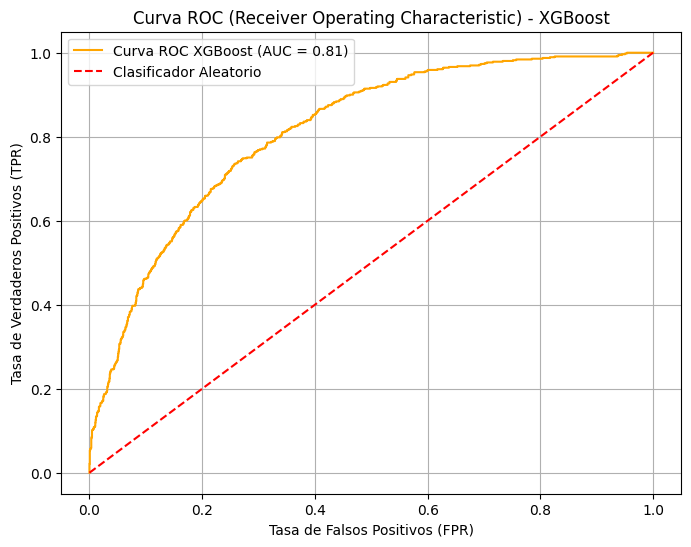

In [82]:
# Predicciones en el conjunto de prueba (no estandarizado)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluar el rendimiento del modelo
print("\nAccuracy del modelo XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("\nReporte de Clasificación (XGBoost):\n", classification_report(y_test, y_pred_xgb))
print("\nÁrea bajo la curva ROC (AUC-ROC) XGBoost:", roc_auc_score(y_test, y_pred_proba_xgb))

# Curva ROC
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='orange', label=f'Curva ROC XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba_xgb):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic) - XGBoost')
plt.legend()
plt.grid(True)
plt.show()


## 📊 Comparación de Modelos: Regresión Logística vs. Random Forest y XGBoost


### **Resultados Clave de los Modelos:**

| Métrica             | Regresión Logística (Estandarizado) | Random Forest           | XGBoost                 |
| :------------------ | :---------------------------------- | :---------------------- | :---------------------- |
| **Accuracy**        | 0.7795                              | 0.7771                  | 0.7771                  |
| **Precision (Churn=1)** | 0.57                                | **0.59**                | **0.59**                |
| **Recall (Churn=1)**    | **0.69**                            | 0.51                    | 0.54                    |
| **F1-Score (Churn=1)**  | **0.62**                            | 0.55                    | 0.56                    |
| **AUC-ROC**         | **0.8365**                          | 0.8126                  | 0.8127                  |

### **Conclusión de la Comparación:**

*   **Accuracy General**: Todos los modelos muestran una `Accuracy` muy similar, alrededor del 77-78%.
*   **Rendimiento en la Clase Minoritaria (Churn=1)**:
    *   El **Random Forest** y **XGBoost** mostraron una ligera mejora en la `Precision` (0.59) comparado con la Regresión Logística (0.57).
    *   Sin embargo, el **`Recall` de los modelos de árbol para la clase 'Churn' es notablemente más bajo (0.51 y 0.54)** que el del modelo estandarizado de Regresión Logística (0.69). Esto significa que los modelos basados en árboles actuales son menos efectivos para identificar a los clientes que realmente cancelan.
    *   El `F1-Score` de los modelos de árbol (0.55 y 0.56) también es inferior al del modelo estandarizado de Regresión Logística (0.62), lo que indica un peor equilibrio entre `Precision` y `Recall` para la clase crítica.
*   **Capacidad Discriminatoria (AUC-ROC)**: Los modelos de árbol tienen el AUC-ROC más bajo (0.8126 y 0.8127). Esto sugiere que su capacidad general para diferenciar entre clientes que van a cancelar y los que no es inferior a la de la Regresión Logística estandarizada (0.8365).

**En este análisis, el modelo de Regresión Logística con datos estandarizados (`model_scaled`) sigue siendo el que presenta el mejor rendimiento general**, destacándose por su mayor `Recall` y `AUC-ROC` en la detección de la cancelación de clientes, que es el objetivo principal de nuestro análisis.

#🎯Correlación y Selección de Variables

Correlación de las variables numéricas con 'Churn':
 account.Charges.Monthly    0.193356
customer.SeniorCitizen     0.150889
account.Charges.Total     -0.198324
customer.tenure           -0.352229
Name: Churn, dtype: float64


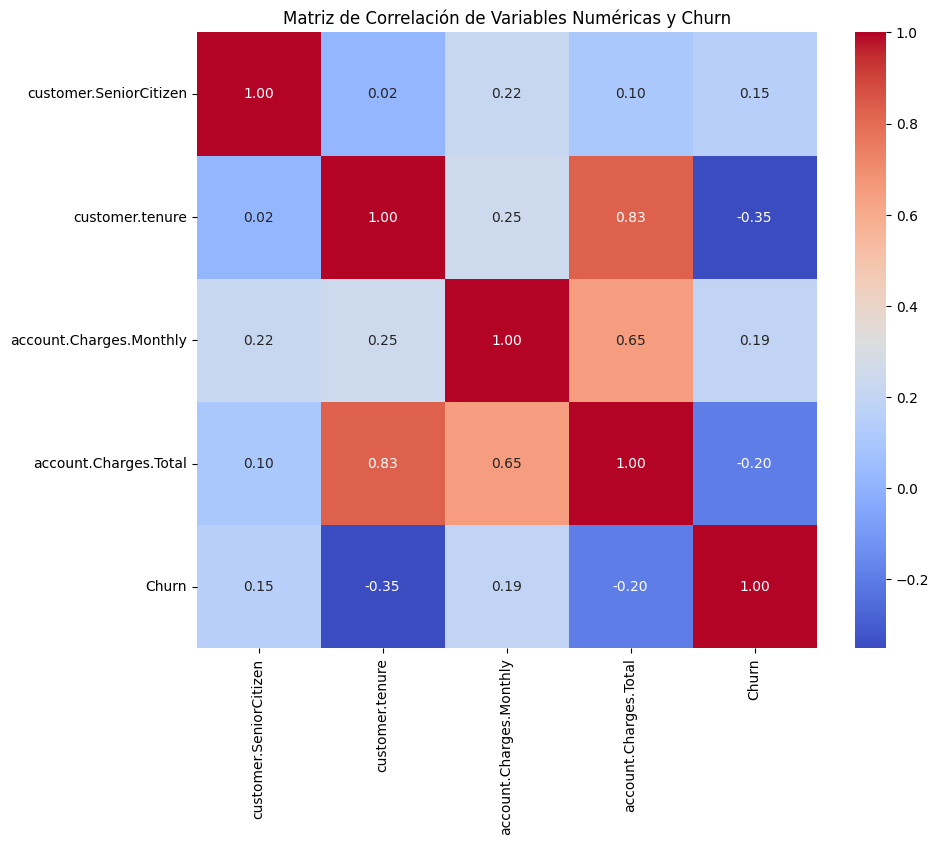

In [86]:


# Identificar las columnas numéricas relevantes (int64 y float64) del df_encoded original
# Excluimos las columnas booleanas generadas por One-Hot Encoding para esta visualización específica
numerical_features = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Asegurarse de que 'Churn' esté en la lista si no es ya un int64 o float64, y luego eliminarla para calcular correlaciones solo entre features
if 'Churn' in numerical_features:
    numerical_features.remove('Churn')

# Incluir 'Churn' para la matriz de correlación final que queremos visualizar
features_for_correlation = numerical_features + ['Churn']

# Calcular la matriz de correlación solo para estas características
correlation_matrix_numeric = df_encoded[features_for_correlation].corr()

# Filtrar la correlación de estas características con 'Churn' y ordenarlas
churn_correlation_numeric = correlation_matrix_numeric['Churn'].drop('Churn').sort_values(ascending=False)
print("Correlación de las variables numéricas con 'Churn':\n", churn_correlation_numeric)

# Visualizar la matriz de correlación de las variables numéricas y 'Churn'
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_numeric, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas y Churn')
plt.show()


## === CORRELACIÓN DE VARIABLES NUMÉRICAS CON 'CHURN' ===

### 1. customer.tenure (-0.3522): Correlación negativa moderada.
####    Es el predictor más importante: a menor antigüedad, más probabilidad de churn.

### 2. account.Charges.Total (-0.1983): Correlación negativa débil.
###   Clientes con menor gasto acumulado (generalmente nuevos) tienen mayor tendencia a irse.

### 3. account.Charges.Monthly (0.1934): Correlación positiva débil.
####   Sugiere que cargos mensuales elevados incrementan ligeramente la cancelación.

### 4. customer.SeniorCitizen (0.1509): Correlación positiva débil.
####   Indica que el segmento de ciudadanos de la tercera edad tiene mayor riesgo de churn.

###Esta visualización confirma que las características numéricas elegidas son relevantes y que nuestro modelo de Regresión Logística las está utilizando de manera significativa, especialmente customer.tenure y account.Charges.Total.

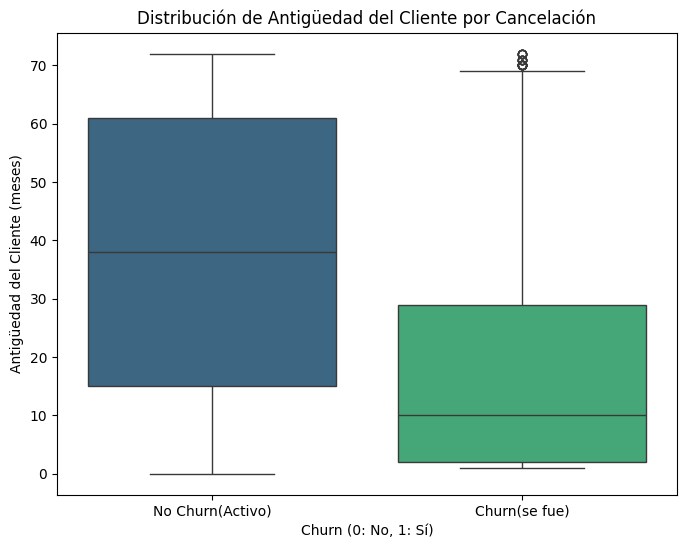


Antigüedad media por estado de Cancelación:
 Churn
0    37.569965
1    17.979133
Name: customer.tenure, dtype: float64


In [103]:
# Boxplot de Antigüedad del cliente (customer.tenure) vs. Cancelación (Churn)
# Usamos el df_encoded ya que 'Churn' está en formato 0/1 y 'customer.tenure' es numérica.
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_encoded, x='Churn', y='customer.tenure', hue='Churn', palette='viridis', legend=False)
plt.title('Distribución de Antigüedad del Cliente por Cancelación')
plt.xlabel('Churn (0: No, 1: Sí)')
plt.ylabel('Antigüedad del Cliente (meses)')
plt.xticks(ticks=[0, 1], labels=['No Churn(Activo)', 'Churn(se fue)'])
plt.show()

# Para una mejor interpretación, calculamos las medias de antigüedad por grupo de Churn
tenure_by_churn = df_encoded.groupby('Churn')['customer.tenure'].mean()
print("\nAntigüedad media por estado de Cancelación:\n", tenure_by_churn)


###Claramente se observa que la caja (que representa el 50% central de los datos) para los clientes que cancelaron está ubicada en valores de antigüedad mucho más bajos. La antigüedad media (indicada por la línea dentro de la caja) y la distribución general para los churners se concentran en los primeros meses de servicio. En contraste, los clientes activos tienen una distribución de antigüedad mucho más extendida y con valores promedio y medianos significativamente más altos.

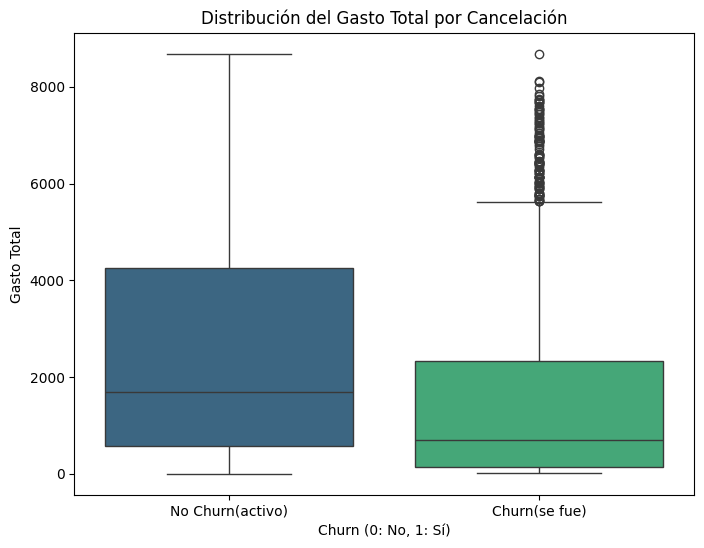


Gasto total medio por estado de Cancelación:
 Churn
0    2549.911442
1    1531.796094
Name: account.Charges.Total, dtype: float64


In [104]:
# Boxplot de Gasto total (account.Charges.Total) vs. Cancelación (Churn)
# Usamos el df_encoded ya que 'Churn' está en formato 0/1 y 'account.Charges.Total' es numérica.
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_encoded, x='Churn', y='account.Charges.Total', hue='Churn', palette='viridis', legend=False)
plt.title('Distribución del Gasto Total por Cancelación')
plt.xlabel('Churn (0: No, 1: Sí)')
plt.ylabel('Gasto Total')
plt.xticks(ticks=[0, 1], labels=['No Churn(activo)', 'Churn(se fue)'])
plt.show()

# Para una mejor interpretación, calculamos las medias de gasto total por grupo de Churn
charges_total_by_churn = df_encoded.groupby('Churn')['account.Charges.Total'].mean()
print("\nGasto total medio por estado de Cancelación:\n", charges_total_by_churn)


###Similar al tenure, el boxplot muestra que los clientes que cancelaron tienen una distribución de gasto total considerablemente más baja. La caja de los churners está en un rango de valores de gasto total inferior en comparación con los clientes activos, cuya distribución se extiende a valores mucho mayores.

##